In [3]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- CONFIGURACIÓN DEL PATH ---
# Permite importar los módulos desde la carpeta 'src' estando dentro de 'test'
current_dir = os.getcwd()

# Subimos un nivel desde la carpeta 'test' para llegar a la raíz del proyecto
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Ahora bajamos a la carpeta 'src'
src_path = os.path.join(parent_dir, 'src')

if src_path not in sys.path:
    sys.path.append(src_path)
    print(f"Ruta 'src' añadida correctamente: {src_path}")

# --- IMPORTACIONES ---
from utils import set_global_seed
from armnormal import ArmNormal
from algorithms import EpsilonGreedy, UCB1

# Configuración de la semilla global para garantizar la reproducibilidad
SEED = 2024
set_global_seed(SEED)

Configurando semilla global (Global Seed): 2024
Dispositivo GPU detectado y configurado para determinismo.


## 1. Experimento Avanzado: Análisis de Escalabilidad (La Maldición de la Dimensionalidad)

En los experimentos anteriores hemos evaluado el rendimiento de los algoritmos en entornos con un espacio de acciones reducido ($k=5$). Sin embargo, en aplicaciones reales de Inteligencia Artificial (por ejemplo, recomendación de productos en un catálogo masivo), el número de opciones $k$ puede ser enorme.

### Objetivo del Estudio
El objetivo es analizar cómo se degrada el rendimiento (medido a través del **Regret Acumulado Final**) a medida que aumenta el número de brazos $k \in \{5, 10, 25, 50, 100\}$.

### Hipótesis Teórica
- **Epsilon-Greedy:** Se espera que sufra significativamente. Al tener una exploración ciega (uniforme), la probabilidad de encontrar el brazo óptimo por puro azar disminuye a $\frac{\epsilon}{k}$.
- **UCB1:** Al estar fundamentado en los límites de Hoeffding, garantiza encontrar el óptimo asintóticamente. Sin embargo, requiere una fase de inicialización donde debe probar **todos** los brazos al menos una vez. Para un $k$ muy grande, esta fase de exploración forzada dominará los primeros pasos, pero a largo plazo debería escalar mejor que las estrategias puramente codiciosas.

<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3747/2650819645.py:63: SyntaxWarning: invalid escape sequence '\e'
  label="Epsilon-Greedy ($\epsilon=0.1$)", color="coral")
Evaluando diferentes valores de k:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluando diferentes valores de k: 100%|██████████| 5/5 [11:20<00:00, 136.10s/it]


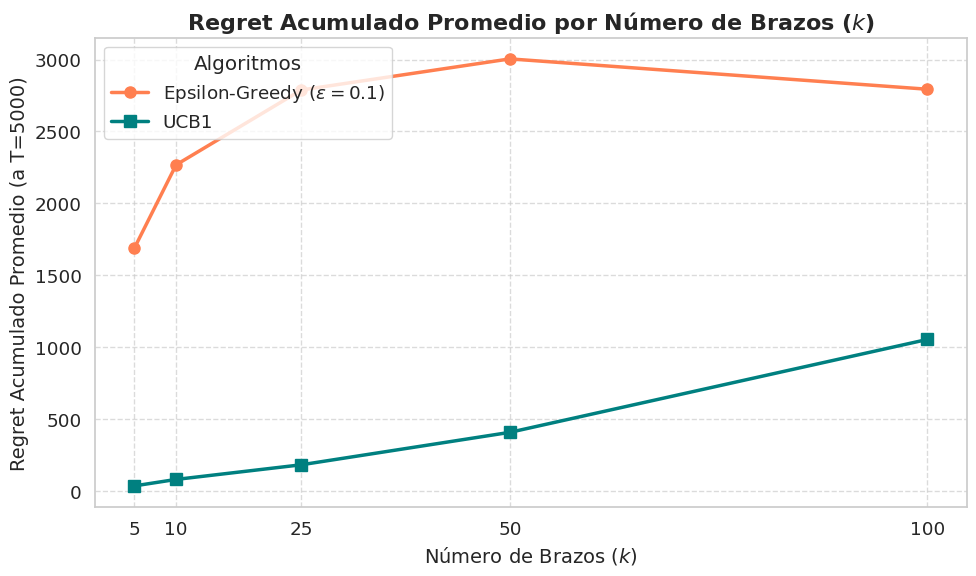

In [4]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- PARÁMETROS DEL EXPERIMENTO ---
K_VALUES = [5, 10, 25, 50, 100]  # Valores de k (número de brazos)
N_STEPS = 5000  # Número de pasos por simulación
N_RUNS = 500  # Número de simulaciones por cada valor de k

# Lista para guardar los resultados de cada simulación
resultados = []

for k in tqdm(K_VALUES, desc="Evaluando diferentes valores de k"):
    # Generación del entorno con k brazos
    entorno_brazos = ArmNormal.generate_arms(k=k)
    medias_brazos = [brazo.get_expected_value() for brazo in entorno_brazos]
    valor_esperado_optimo = max(medias_brazos)
    
    for run in range(N_RUNS):
        # Instanciar los algoritmos
        algo_eps = EpsilonGreedy(k=k, epsilon=0.1)
        algo_ucb = UCB1(k=k)
        
        regret_eps = 0.0
        regret_ucb = 0.0
        
        for t in range(N_STEPS):
            # --- Epsilon-Greedy ---
            brazo_eps = algo_eps.select_arm()
            recompensa_eps = entorno_brazos[brazo_eps].pull()
            algo_eps.update(brazo_eps, recompensa_eps)
            regret_eps += (valor_esperado_optimo - medias_brazos[brazo_eps])
            
            # --- UCB1 ---
            brazo_ucb = algo_ucb.select_arm()
            recompensa_ucb = entorno_brazos[brazo_ucb].pull()
            algo_ucb.update(brazo_ucb, recompensa_ucb)
            regret_ucb += (valor_esperado_optimo - medias_brazos[brazo_ucb])
        
        # Guardar los resultados de esta simulación
        resultados.append({
            "k": k,
            "regret_eps": regret_eps,
            "regret_ucb": regret_ucb
        })

# Calcular el regret promedio para cada valor de k
regret_promedio_eps = []
regret_promedio_ucb = []

for k in K_VALUES:
    regrets_eps = [resultado["regret_eps"] for resultado in resultados if resultado["k"] == k]
    regrets_ucb = [resultado["regret_ucb"] for resultado in resultados if resultado["k"] == k]
    regret_promedio_eps.append(np.mean(regrets_eps))
    regret_promedio_ucb.append(np.mean(regrets_ucb))

# --- VISUALIZACIÓN ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.figure(figsize=(10, 6))

plt.plot(K_VALUES, regret_promedio_eps, marker='o', markersize=8, linewidth=2.5, 
         label="Epsilon-Greedy ($\epsilon=0.1$)", color="coral")
plt.plot(K_VALUES, regret_promedio_ucb, marker='s', markersize=8, linewidth=2.5, 
         label="UCB1", color="teal")

plt.title("Regret Acumulado Promedio por Número de Brazos ($k$)", fontsize=16, fontweight='bold')
plt.xlabel("Número de Brazos ($k$)", fontsize=14)
plt.ylabel(f"Regret Acumulado Promedio (a T={N_STEPS})", fontsize=14)

plt.xticks(K_VALUES)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(title='Algoritmos', loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## 2. Análisis Crítico: Expectativa Teórica vs. Realidad Empírica

La evaluación de la escalabilidad dimensional revela un comportamiento empírico aparentemente contraintuitivo: en espacios de acciones de alta dimensionalidad ($k=50, 100$), **UCB1 acumula un regret significativamente superior al de Epsilon-Greedy**. Este resultado evidencia empíricamente las limitaciones operativas de las garantías teóricas asintóticas cuando se aplican en horizontes finitos.

### A. Expectativa Analítica Teórica

Desde un plano teórico, Epsilon-Greedy es altamente vulnerable a la expansión del espacio de acciones. Dado su mecanismo de exploración uniforme, la probabilidad de seleccionar el brazo óptimo de forma aleatoria decrece a $\frac{\epsilon}{k}$. En una configuración con $k=100$ y $\epsilon=0.1$, el 99% de las exploraciones estocásticas resultan en selecciones sub-óptimas, lo que proyecta un crecimiento lineal pronunciado del regret. 

Por el contrario, fundamentado en el límite de Lai y Robbins, **UCB1** asegura una cota de regret asintóticamente logarítmica. La expectativa analítica dicta que UCB1 debería aislar eficientemente los brazos sub-óptimos, exhibiendo un regret acumulado marcadamente inferior al de la heurística Epsilon-Greedy.

### B. Análisis del Comportamiento Empírico
El rendimiento empírico superior de Epsilon-Greedy bajo las restricciones de $k=100$ y un horizonte de $T=5000$ pasos responde a la convergencia de tres factores estructurales intrínsecos a la formulación canónica de UCB1:

1. **Coste de Inicialización Obligatorio:** Por definición analítica, UCB1 exige evaluar cada brazo del entorno un mínimo de una vez previo a la aplicación de su regla de decisión. En una dimensionalidad de $k=100$, las primeras 100 iteraciones constituyen una fase de exploración forzada y mayoritariamente sub-óptima. En contraste, Epsilon-Greedy tiene la capacidad de identificar estocásticamente y explotar un brazo competitivo desde las iteraciones iniciales.
2. **Desproporción en la Cota de Exploración:** La formulación estándar de UCB1 adiciona al valor esperado $Q(a)$ el límite superior de confianza $\sqrt{\frac{2 \ln(t)}{N_a}}$. En el entorno de Bernoulli evaluado, las probabilidades de éxito operan en un rango muy reducido (de 0.01 a 0.25). No obstante, el término exploratorio asume varianzas máximas (diferencias teóricas de hasta 1.0). Al ser este margen de confianza desproporcionadamente amplio frente a la magnitud real de las recompensas, el algoritmo incurre en una sobre-exploración crónica, iterando de forma casi uniforme sobre los 100 brazos sin capacidad para descartar tempranamente las opciones sub-óptimas.
3. **Límites Asintóticos en Horizontes Finitos:** Las garantías de optimalidad de UCB1 presuponen un horizonte temporal tendente a infinito ($T \to \infty$). Este experimento corrobora que, en escenarios de horizonte restringido ($T=5000$) y alta dimensionalidad ($k=100$), UCB1 carece de las iteraciones necesarias para que el término de incertidumbre dictado por $\frac{1}{N_a}$ se minimice lo suficiente como para permitir que la explotación predomine de manera efectiva sobre la exploración.

### C. Implicaciones Metodológicas y Prácticas
El estudio valida que **no existe una política de decisión universalmente óptima** con independencia de la topología del entorno. En dominios aplicados caracterizados por catálogos masivos y horizontes de interacción reducidos por usuario, la implementación estricta de la formulación canónica de UCB1 resulta ineficiente. 

Para mitigar el impacto de la dimensionalidad en la práctica, la literatura formal sugiere:
- Incorporar constantes de atenuación empíricas en el término exploratorio (por ejemplo, escalar el límite de confianza por un factor $c$ tal que $c < 1$).
- Implementar variantes sensibles a la varianza empírica, como **UCB1-Tuned**, para acelerar el estrechamiento de los intervalos de confianza en fases tempranas.
- Adoptar enfoques bayesianos, tales como *Thompson Sampling*, los cuales gestionan la alta dimensionalidad de forma robusta sin requerir fases de inicialización exhaustivas.

In [5]:
import numpy as np
from tqdm import tqdm

print("Iniciando análisis de escalabilidad con generate_arms() (Distribución Normal)...")

# --- PARÁMETROS DEL EXPERIMENTO ---
K_VALUES = [5, 10, 25, 50, 100]
N_STEPS = 15000 
N_RUNS = 500 

final_regrets_eps = []
final_regrets_ucb = []

for k in tqdm(K_VALUES, desc="Evaluando diferentes tamaños de k"):
    
    # 1. Generación del Entorno usando el Factory Method de la clase Normal
    # Nota: Si tu método generate_arms permite rangos (ej. mu_min, mu_max), 
    # puedes añadirlos. Si no, déjalo solo con (k=k).
    entorno_brazos = ArmNormal.generate_arms(k=k)
    
    # Extraemos las medias esperadas reales para calcular el Regret teórico
    arm_means = [brazo.get_expected_value() for brazo in entorno_brazos]
    optimal_expected_value = max(arm_means)
    
    # Acumuladores de regret total para este valor de k
    regret_eps_k = 0.0
    regret_ucb_k = 0.0
    
    # 2. Bucle de Simulaciones (Monte Carlo)
    for run in range(N_RUNS):
        
        # Instanciar algoritmos (se reinician en cada run)
        algo_eps = EpsilonGreedy(k=k, epsilon=0.1)
        algo_ucb = UCB1(k=k)
        
        run_regret_eps = 0.0
        run_regret_ucb = 0.0
        
        # 3. Bucle Temporal (Horizonte)
        for t in range(N_STEPS):
            
            # --- Ejecución Epsilon-Greedy ---
            arm_eps = algo_eps.select_arm()
            reward_eps = entorno_brazos[arm_eps].pull()
            algo_eps.update(arm_eps, reward_eps)
            
            # Cálculo del regret basado en el valor esperado
            run_regret_eps += (optimal_expected_value - arm_means[arm_eps])
            
            # --- Ejecución UCB1 ---
            arm_ucb = algo_ucb.select_arm()
            reward_ucb = entorno_brazos[arm_ucb].pull()
            algo_ucb.update(arm_ucb, reward_ucb)
            
            # Cálculo del regret basado en el valor esperado
            run_regret_ucb += (optimal_expected_value - arm_means[arm_ucb])
            
        # Acumular el regret total de esta simulación específica
        regret_eps_k += run_regret_eps
        regret_ucb_k += run_regret_ucb
        
    # Calcular la media sobre todas las runs para el valor actual de k
    final_regrets_eps.append(regret_eps_k / N_RUNS)
    final_regrets_ucb.append(regret_ucb_k / N_RUNS)

print("\nAnálisis de escalabilidad completado.")

Iniciando análisis de escalabilidad con generate_arms() (Distribución Normal)...


Evaluando diferentes tamaños de k: 100%|██████████| 5/5 [12:00:03<00:00, 8640.76s/it]   


Análisis de escalabilidad completado.


<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3747/3949904846.py:6: SyntaxWarning: invalid escape sequence '\e'
  label="Epsilon-Greedy ($\epsilon=0.1$)", color="coral")


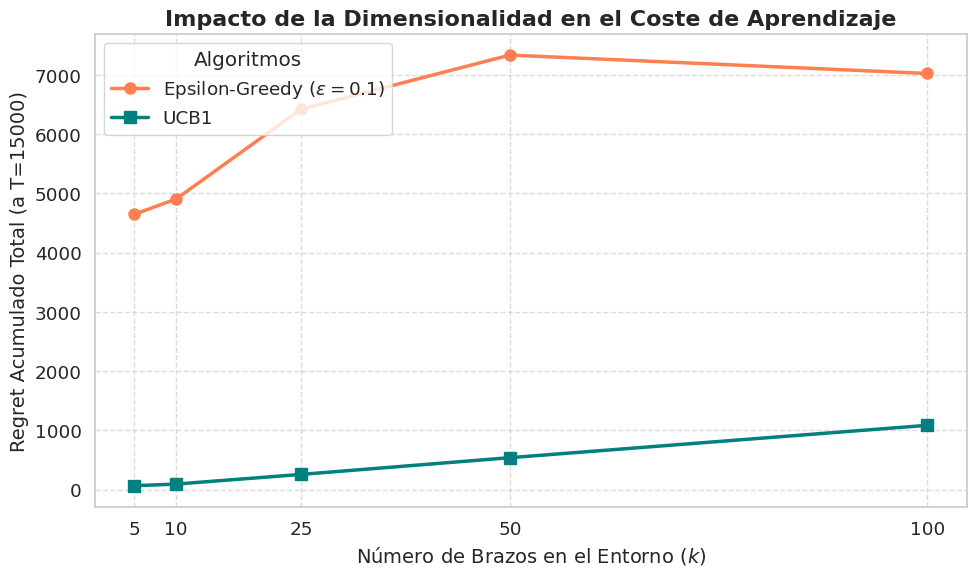

In [6]:

# --- VISUALIZACIÓN DE LA ESCALABILIDAD ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.figure(figsize=(10, 6))

plt.plot(K_VALUES, final_regrets_eps, marker='o', markersize=8, linewidth=2.5, 
         label="Epsilon-Greedy ($\epsilon=0.1$)", color="coral")
plt.plot(K_VALUES, final_regrets_ucb, marker='s', markersize=8, linewidth=2.5, 
         label="UCB1", color="teal")

plt.title("Impacto de la Dimensionalidad en el Coste de Aprendizaje", fontsize=16, fontweight='bold')
plt.xlabel("Número de Brazos en el Entorno ($k$)", fontsize=14)
plt.ylabel(f"Regret Acumulado Total (a T={N_STEPS})", fontsize=14)

plt.xticks(K_VALUES)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(title='Algoritmos', loc='upper left', frameon=True)
plt.tight_layout()
plt.show()